# Sentiment Analysis with Recurrent Neural Networks (RNNs)

One of the common uses for binary classification in machine learning is analyzing text for sentiment — specifically, assigning a text string a score from 0 to 1, where 0 represents negative sentiment and 1 represents positive sentiment. A restaurant review such as "Best meal I've ever had and awesome service, too!" might score 0.9 or higher, while a statement such as "Long lines and poor customer service" would score closer to 0. Marketing departments sometimes use sentiment-anlysis models to monitor social-media services for feedback so they can respond quickly if, for example, comments regarding their company suddenly turn negative.

To train a neural network to perform sentiment analysis, you need a dataset containing text strings labeled with 0s (for negative sentiment) and 1s (for positive sentiment). Several such datasets are available in the public domain. We will use one containing 50,000 movie reviews, each labeled with a 0 or 1. Once the network is trained, scoring a text string for sentiment is a simple matter of passing it to the model and asking for the probability that the predicted label is 1. A probability of 80% means the sentiment score is 0.8 and that the text is very positive.

## Load and prepare the data

The first step is to load the dataset and prepare it for use.

In [12]:
import pandas as pd

df = pd.read_csv('Data/reviews.csv', encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


Remove duplicate rows and check for balance.

In [13]:
df = df.drop_duplicates()
df.groupby('Sentiment').describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  What could've been a great film about the late...   
1          24884  24884  I really enjoyed this film. All aspects of the...   

                
          freq  
Sentiment       
0            1  
1            1

## Train an RNN

Create a neural network containing a `TextVectorization` layer for vectorizing text, an `Embedding` layer for converting text sequences into arrays of word vectors, and an `LSTM` layer for generating vectors from ordered word embeddings.

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TextVectorization, InputLayer
from tensorflow.keras.layers import Dense, Embedding, LSTM

max_words = 20000
max_length = 500

model = Sequential()
model.add(InputLayer(shape=(), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 4096))
model.add(LSTM(512))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization_1                 │ (None, 500)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 500, 4096)           │      81,920,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 512)                 │       9,439,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,359,745 (348.51 MB)

 Trainable params: 91,359,745 (348.51 MB)

 Non-trainable params: 0 (0.00 B)

Extract text from the "Text" column and labels from the "Sentiment" column. Fit the `TextVectorization` layer to the text, and then train the model and capture the training history returned by `fit`.

In [15]:
x = tf.strings.as_string(df['Text'])
y = df['Sentiment']
model.layers[0].adapt(x)

hist = model.fit(x, y, validation_split=0.5, epochs=5, batch_size=50)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.4918 - loss: 0.7133 - val_accuracy: 0.5036 - val_loss: 0.6948
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.5184 - loss: 0.6824 - val_accuracy: 0.5058 - val_loss: 0.6981
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.5331 - loss: 0.6551 - val_accuracy: 0.5032 - val_loss: 0.7324
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.5635 - loss: 0.6400 - val_accuracy: 0.8220 - val_loss: 0.4154
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.8858 - loss: 0.2862 - val_accuracy: 0.8730 - val_loss: 0.3135


See how the training and validation accuracy evolved and make sure the model was trained for a sufficient number of epochs.

[]

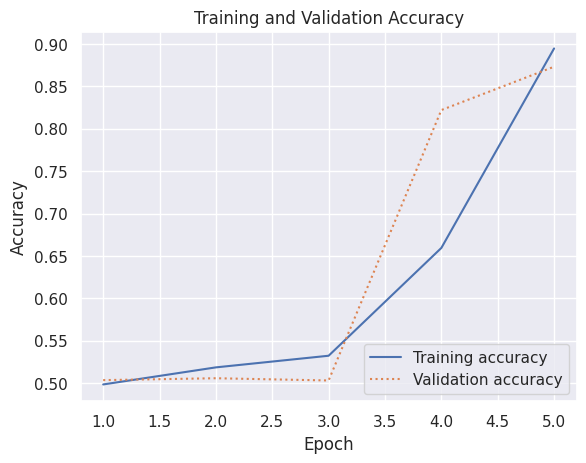

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

acc = hist.history['accuracy']
val = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, '-', label='Training accuracy')
plt.plot(epochs, val, ':', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

## Use the model to analyze text

Let's score a few reviews by passing them to the model's `predict` method. Start with a positive review.

In [17]:
text = 'Great food and excellent service'
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


0.9802964

And then a negative review.

In [18]:
text = 'The long lines and poor customer service really turned me off'
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


0.019311666

Here's another negative review.

In [19]:
text = 'The food was bad, not good at all.'
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


0.042461094

What happens if we swap two words and completely change the sentiment of the review?

In [20]:
text = 'The food was good, not bad at all.'
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


0.30895284

From this, we see that an RNN factors word order into its calculations.